# AI-Powered Quantum Circuit Optimization Advisor
## Clean implementation aligned to the project PPT

This notebook rebuilds the implementation from scratch in the same logical order as the PPT:

**Quantum Circuit → Feature Extraction → Benchmark Dataset → ML Prediction → Optimization Recommendation**

### Important dataset design rule
We **balance the controllable experiment variables**:
- Algorithm
- Backend profile
- Optimization level
- Noise level
- Shots
- Qubit count (within the valid range of each algorithm)

We do **not artificially force derived quantities** such as circuit depth, gate count, fidelity, execution time, or error rate to be uniformly distributed. Those values must be produced naturally by the circuits and simulations.

### Dataset schema
The PPT lists **34 dataset fields** plus two learning outputs:
- `Success_Probability` — regression target
- `Recommended_Optimization` — later recommendation target

An `Experiment_ID` is also stored only to prevent data leakage when splitting related rows. It is **not** a machine-learning feature.

## Part 0 — Install packages
Run this once in Google Colab.

In [36]:
!pip -q install "qiskit==2.5.2" "qiskit-aer==0.17.2" "scikit-learn>=1.5" "pandas>=2.2" "matplotlib>=3.8" "joblib>=1.4"

## Part 1 — Imports and project configuration

In [37]:
import itertools
import math
import random
import time
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, efficient_su2, qaoa_ansatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info.analysis import hellinger_fidelity

from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    depolarizing_error,
    thermal_relaxation_error,
)

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import joblib

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 375 base circuit/environment groups × 4 optimization levels = exactly 1500 rows
NUM_GROUPS = 375

OPTIMIZATION_LEVELS = [0, 1, 2, 3]
SHOTS_LEVELS = [256, 512, 1024, 2048, 4096]
NOISE_LEVELS = ["Ideal", "Low", "Medium", "High"]
BACKEND_PROFILES = ["Aer_FullyConnected", "Aer_LinearNISQ"]

ALGORITHMS = [
    "Bell",
    "GHZ",
    "DeutschJozsa",
    "BernsteinVazirani",
    "Grover",
    "QFT",
    "VQE",
    "QAOA",
    "Simon",
]

# Valid TOTAL qubit counts for each benchmark family.
ALGORITHM_QUBITS = {
    "Bell": [2],
    "GHZ": list(range(3, 11)),
    "DeutschJozsa": list(range(3, 11)),
    "BernsteinVazirani": list(range(3, 11)),
    "Grover": list(range(2, 6)),
    "QFT": list(range(2, 11)),
    "VQE": list(range(2, 11)),
    "QAOA": list(range(3, 11)),
    "Simon": [4, 6, 8, 10],
}

FEATURE_BASIS = ["h", "x", "y", "z", "rx", "ry", "rz", "cx", "swap", "ccx"]
HARDWARE_BASIS = ["rz", "sx", "x", "cx"]

print("Groups:", NUM_GROUPS)
print("Expected rows:", NUM_GROUPS * len(OPTIMIZATION_LEVELS))

Groups: 375
Expected rows: 1500


## Part 2 — Exact dataset columns

The 34 PPT fields are kept exactly as the main dataset fields.

`Success_Probability` and `Recommended_Optimization` are stored as targets/outputs.
`Experiment_ID` is an identifier only.

In [38]:
PPT_34_FIELDS = [
    "Algorithm",
    "Num_Qubits",
    "Circuit_Depth",
    "Circuit_Width",
    "Total_Gates",
    "Single_Qubit_Gates",
    "Multi_Qubit_Gates",
    "Gate_Density",
    "H_Gates",
    "X_Gates",
    "Y_Gates",
    "Z_Gates",
    "RX_Gates",
    "RY_Gates",
    "RZ_Gates",
    "CX_Gates",
    "SWAP_Gates",
    "CCX_Gates",
    "Measure_Gates",
    "Backend",
    "Optimization_Level",
    "Noise_Model",
    "Shots",
    "Gate_Error_Rate",
    "Readout_Error",
    "Average_T1",
    "Average_T2",
    "Execution_Time",
    "Fidelity",
    "Error_Rate",
    "Optimized_Depth",
    "Optimized_Total_Gates",
    "Depth_Reduction",
    "Gate_Reduction",
]

TARGET_COLUMNS = [
    "Success_Probability",
    "Recommended_Optimization",
]

EXPORT_COLUMNS = ["Experiment_ID"] + PPT_34_FIELDS + TARGET_COLUMNS

assert len(PPT_34_FIELDS) == 34
assert len(EXPORT_COLUMNS) == 37

print("PPT fields:", len(PPT_34_FIELDS))
print("Targets:", len(TARGET_COLUMNS))
print("CSV columns including Experiment_ID:", len(EXPORT_COLUMNS))

PPT fields: 34
Targets: 2
CSV columns including Experiment_ID: 37


## Part 3 — Balanced experimental design

The 1500 rows are generated as:

**375 independent base experiments × optimization levels 0, 1, 2, 3**

This is important because the same circuit/environment is tested at every optimization level, allowing us to determine a meaningful best optimization level later.

Balance is enforced for controlled variables. Qubit counts are also cycled evenly inside each algorithm's valid range.

In [39]:
def balanced_sequence(values, n, seed):
    # Return n items with counts differing by at most 1.
    rng = random.Random(seed)
    values = list(values)
    base = n // len(values)
    remainder = n % len(values)

    seq = []
    shuffled = values[:]
    rng.shuffle(shuffled)

    for i, value in enumerate(shuffled):
        seq.extend([value] * (base + (1 if i < remainder else 0)))

    rng.shuffle(seq)
    return seq


def make_balanced_design(num_groups=375, seed=42):
    algorithms = balanced_sequence(ALGORITHMS, num_groups, seed + 1)
    backends = balanced_sequence(BACKEND_PROFILES, num_groups, seed + 2)
    noises = balanced_sequence(NOISE_LEVELS, num_groups, seed + 3)
    shots = balanced_sequence(SHOTS_LEVELS, num_groups, seed + 4)

    algo_counts = Counter(algorithms)
    qubit_pool = {}
    for idx, algo in enumerate(ALGORITHMS):
        qubit_pool[algo] = balanced_sequence(
            ALGORITHM_QUBITS[algo],
            algo_counts[algo],
            seed + 100 + idx,
        )

    qubit_index = defaultdict(int)
    groups = []

    for i in range(num_groups):
        algo = algorithms[i]
        qidx = qubit_index[algo]
        qubits = qubit_pool[algo][qidx]
        qubit_index[algo] += 1

        groups.append({
            "Experiment_ID": f"EXP_{i+1:04d}",
            "Algorithm": algo,
            "Num_Qubits": qubits,
            "Backend": backends[i],
            "Noise_Model": noises[i],
            "Shots": shots[i],
            "Circuit_Seed": seed * 10000 + i,
        })

    return pd.DataFrame(groups)


design_df = make_balanced_design(NUM_GROUPS, SEED)

print("Base experiment distribution")
print("----------------------------")
print("\nAlgorithm:\n", design_df["Algorithm"].value_counts().sort_index())
print("\nBackend:\n", design_df["Backend"].value_counts())
print("\nNoise:\n", design_df["Noise_Model"].value_counts())
print("\nShots:\n", design_df["Shots"].value_counts().sort_index())

assert len(design_df) == NUM_GROUPS
assert design_df["Shots"].value_counts().max() - design_df["Shots"].value_counts().min() <= 1
assert design_df["Noise_Model"].value_counts().max() - design_df["Noise_Model"].value_counts().min() <= 1
assert design_df["Backend"].value_counts().max() - design_df["Backend"].value_counts().min() <= 1

design_df.head()

Base experiment distribution
----------------------------

Algorithm:
 Algorithm
Bell                 41
BernsteinVazirani    42
DeutschJozsa         42
GHZ                  42
Grover               41
QAOA                 42
QFT                  41
Simon                42
VQE                  42
Name: count, dtype: int64

Backend:
 Backend
Aer_FullyConnected    188
Aer_LinearNISQ        187
Name: count, dtype: int64

Noise:
 Noise_Model
Ideal     94
High      94
Low       94
Medium    93
Name: count, dtype: int64

Shots:
 Shots
256     75
512     75
1024    75
2048    75
4096    75
Name: count, dtype: int64


,Experiment_ID,Algorithm,Num_Qubits,Backend,Noise_Model,Shots,Circuit_Seed
0,EXP_0001,QAOA,4,Aer_FullyConnected,Ideal,256,420000
1,EXP_0002,DeutschJozsa,7,Aer_FullyConnected,Medium,2048,420001
2,EXP_0003,VQE,2,Aer_FullyConnected,Medium,512,420002
3,EXP_0004,DeutschJozsa,5,Aer_FullyConnected,Ideal,4096,420003
4,EXP_0005,Grover,5,Aer_FullyConnected,High,256,420004


## Part 4 — Quantum circuit generators

The benchmark contains nine circuit families.

Notes:
- QFT is implemented as a **QFT round-trip** (QFT followed by inverse QFT) so its task success has a clear expected output.
- VQE and QAOA rows benchmark their **variational ansatz circuits**. This project studies circuit execution/optimization, not a full chemistry or combinatorial-optimization workflow.
- Every generator returns metadata that defines what a successful measurement means.

In [40]:
def generate_bell(total_qubits, rng):
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])
    return qc, {"success_type": "states", "success_states": {"00", "11"}}


def generate_ghz(total_qubits, rng):
    n = total_qubits
    qc = QuantumCircuit(n, n)
    qc.h(0)
    for i in range(n - 1):
        qc.cx(i, i + 1)
    qc.measure(range(n), range(n))
    return qc, {
        "success_type": "states",
        "success_states": {"0" * n, "1" * n},
    }


def generate_deutsch_jozsa(total_qubits, rng):
    n_inputs = total_qubits - 1
    anc = n_inputs
    qc = QuantumCircuit(total_qubits, n_inputs)

    qc.x(anc)
    qc.h(range(total_qubits))

    oracle_type = rng.choice(["constant", "balanced"])

    if oracle_type == "constant":
        constant_value = int(rng.integers(0, 2))
        if constant_value == 1:
            qc.x(anc)
    else:
        mask = rng.integers(0, 2, size=n_inputs)
        if not mask.any():
            mask[rng.integers(0, n_inputs)] = 1
        for q, bit in enumerate(mask):
            if bit:
                qc.cx(q, anc)

    qc.h(range(n_inputs))
    qc.measure(range(n_inputs), range(n_inputs))

    if oracle_type == "constant":
        meta = {
            "success_type": "states",
            "success_states": {"0" * n_inputs},
        }
    else:
        meta = {
            "success_type": "nonzero",
            "num_measured_bits": n_inputs,
        }

    meta["oracle_type"] = oracle_type
    return qc, meta


def generate_bernstein_vazirani(total_qubits, rng):
    n_inputs = total_qubits - 1
    anc = n_inputs
    secret = "".join(str(int(x)) for x in rng.integers(0, 2, size=n_inputs))

    qc = QuantumCircuit(total_qubits, n_inputs)
    qc.x(anc)
    qc.h(range(total_qubits))

    for q in range(n_inputs):
        if secret[n_inputs - 1 - q] == "1":
            qc.cx(q, anc)

    qc.h(range(n_inputs))
    qc.measure(range(n_inputs), range(n_inputs))

    return qc, {
        "success_type": "states",
        "success_states": {secret},
        "secret": secret,
    }


def grover_phase_oracle(qc, marked_count_order):
    n = len(marked_count_order)
    marked_qorder = marked_count_order[::-1]

    for q, bit in enumerate(marked_qorder):
        if bit == "0":
            qc.x(q)

    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    for q, bit in enumerate(marked_qorder):
        if bit == "0":
            qc.x(q)


def grover_diffuser(qc):
    n = qc.num_qubits
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))


def generate_grover(total_qubits, rng):
    n = total_qubits
    marked = format(int(rng.integers(0, 2**n)), f"0{n}b")

    qc = QuantumCircuit(n, n)
    qc.h(range(n))

    iterations = max(1, int(math.floor((math.pi / 4) * math.sqrt(2**n))))

    for _ in range(iterations):
        grover_phase_oracle(qc, marked)
        grover_diffuser(qc)

    qc.measure(range(n), range(n))

    return qc, {
        "success_type": "states",
        "success_states": {marked},
        "marked_state": marked,
        "grover_iterations": iterations,
    }


def generate_qft_roundtrip(total_qubits, rng):
    n = total_qubits
    value = int(rng.integers(0, 2**n))
    expected = format(value, f"0{n}b")

    qc = QuantumCircuit(n, n)

    for q in range(n):
        if (value >> q) & 1:
            qc.x(q)

    qft_gate = QFTGate(n)
    qc.append(qft_gate, range(n))
    qc.append(qft_gate.inverse(), range(n))

    qc.measure(range(n), range(n))

    return qc, {
        "success_type": "states",
        "success_states": {expected},
        "input_state": expected,
    }


def generate_vqe_ansatz(total_qubits, rng):
    n = total_qubits

    ansatz = efficient_su2(
        n,
        su2_gates=["ry", "rz"],
        entanglement="linear",
        reps=2,
    )

    values = rng.normal(loc=0.0, scale=0.30, size=len(ansatz.parameters))
    bound = ansatz.assign_parameters(dict(zip(ansatz.parameters, values)))

    qc = QuantumCircuit(n, n)
    qc.compose(bound, inplace=True)
    qc.measure(range(n), range(n))

    return qc, {
        "success_type": "states",
        "success_states": {"0" * n},
        "benchmark": "VQE ansatz for simple Ising reference Hamiltonian",
    }


def maxcut_optimal_states_ring(n):
    edges = [(i, (i + 1) % n) for i in range(n)]
    best_score = -1
    best_states = set()

    for value in range(2**n):
        bits_qorder = [(value >> q) & 1 for q in range(n)]
        score = sum(bits_qorder[i] != bits_qorder[j] for i, j in edges)
        count_order_state = format(value, f"0{n}b")

        if score > best_score:
            best_score = score
            best_states = {count_order_state}
        elif score == best_score:
            best_states.add(count_order_state)

    return edges, best_states


def generate_qaoa_ansatz(total_qubits, rng):
    n = total_qubits
    edges, optimal_states = maxcut_optimal_states_ring(n)

    pauli_terms = []
    for i, j in edges:
        label = ["I"] * n
        label[i] = "Z"
        label[j] = "Z"
        pauli_terms.append(("".join(label[::-1]), 1.0))

    cost_operator = SparsePauliOp.from_list(pauli_terms)
    ansatz = qaoa_ansatz(cost_operator, reps=1)

    values = rng.uniform(0.15, 1.25, size=len(ansatz.parameters))
    bound = ansatz.assign_parameters(dict(zip(ansatz.parameters, values)))

    qc = QuantumCircuit(n, n)
    qc.compose(bound, inplace=True)
    qc.measure(range(n), range(n))

    return qc, {
        "success_type": "states",
        "success_states": optimal_states,
        "benchmark": "QAOA MaxCut ring ansatz",
    }


def generate_simon(total_qubits, rng):
    n = total_qubits // 2
    qc = QuantumCircuit(2 * n, n)

    secret = rng.integers(0, 2, size=n)
    if not secret.any():
        secret[int(rng.integers(0, n))] = 1

    pivot = int(np.where(secret == 1)[0][0])

    rows = []
    for j in range(n):
        if j == pivot:
            continue
        row = np.zeros(n, dtype=int)
        row[j] = 1
        row[pivot] = int(secret[j])
        rows.append(row)

    qc.h(range(n))

    for out_idx, row in enumerate(rows):
        output_qubit = n + out_idx
        for inp_idx, bit in enumerate(row):
            if bit:
                qc.cx(inp_idx, output_qubit)

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc, {
        "success_type": "simon",
        "secret_qorder": secret.tolist(),
        "num_measured_bits": n,
    }


ALGORITHM_GENERATORS = {
    "Bell": generate_bell,
    "GHZ": generate_ghz,
    "DeutschJozsa": generate_deutsch_jozsa,
    "BernsteinVazirani": generate_bernstein_vazirani,
    "Grover": generate_grover,
    "QFT": generate_qft_roundtrip,
    "VQE": generate_vqe_ansatz,
    "QAOA": generate_qaoa_ansatz,
    "Simon": generate_simon,
}

assert set(ALGORITHM_GENERATORS) == set(ALGORITHMS)
print("Circuit generators ready:", len(ALGORITHM_GENERATORS))

Circuit generators ready: 9


## Part 5 — Correct success-probability definition

A single universal “most frequent output” rule is not used.

Instead, success is defined according to each benchmark:
- Bell/GHZ: probability mass on valid entangled outputs
- Bernstein-Vazirani/Grover/QFT/VQE/QAOA: probability mass on the known successful state(s)
- Deutsch-Jozsa: correct constant/balanced classification
- Simon: probability of measuring a bit string orthogonal to the hidden period

In [41]:
def clean_count_key(key):
    return key.replace(" ", "")


def calculate_success_probability(counts, meta):
    counts = {clean_count_key(k): int(v) for k, v in counts.items()}
    total = sum(counts.values())
    if total == 0:
        return 0.0

    success_type = meta["success_type"]

    if success_type == "states":
        valid = meta["success_states"]
        successful = sum(counts.get(state, 0) for state in valid)
        return successful / total

    if success_type == "nonzero":
        zero_state = "0" * meta["num_measured_bits"]
        return 1.0 - counts.get(zero_state, 0) / total

    if success_type == "simon":
        secret = np.array(meta["secret_qorder"], dtype=int)
        successful = 0

        for state, count in counts.items():
            y_qorder = np.array([int(b) for b in state[::-1]], dtype=int)
            if int(np.dot(secret, y_qorder) % 2) == 0:
                successful += count

        return successful / total

    raise ValueError(f"Unknown success type: {success_type}")

## Part 6 — Backend profiles and physically applied noise

The hardware values stored in the dataset are the same values actually used by the simulator.

For non-ideal runs, the noise model includes:
- single-qubit depolarizing error
- two-qubit depolarizing error
- T1/T2 thermal relaxation
- measurement/readout error

The two backend profiles also differ in connectivity:
- `Aer_FullyConnected`: all-to-all connectivity
- `Aer_LinearNISQ`: nearest-neighbor linear connectivity

In [42]:
BACKEND_BASE = {
    "Aer_FullyConnected": {
        "p1": 0.00035,
        "p2": 0.0035,
        "readout": 0.008,
        "t1_us": 130.0,
        "t2_us": 105.0,
    },
    "Aer_LinearNISQ": {
        "p1": 0.00065,
        "p2": 0.0075,
        "readout": 0.016,
        "t1_us": 95.0,
        "t2_us": 75.0,
    },
}

NOISE_SCALE = {
    "Ideal": 0.0,
    "Low": 0.60,
    "Medium": 1.00,
    "High": 1.80,
}


def sample_hardware_parameters(backend_name, noise_level, seed):
    rng = np.random.default_rng(seed)
    base = BACKEND_BASE[backend_name]
    scale = NOISE_SCALE[noise_level]

    if noise_level == "Ideal":
        return {
            "p1": 0.0,
            "p2": 0.0,
            "readout": 0.0,
            "t1_us": 1_000_000.0,
            "t2_us": 1_000_000.0,
        }

    jitter_err = float(rng.uniform(0.90, 1.10))
    jitter_ro = float(rng.uniform(0.90, 1.10))
    jitter_t1 = float(rng.uniform(0.90, 1.10))
    jitter_t2 = float(rng.uniform(0.90, 1.10))

    p1 = min(base["p1"] * scale * jitter_err, 0.20)
    p2 = min(base["p2"] * scale * jitter_err, 0.30)
    readout = min(base["readout"] * scale * jitter_ro, 0.30)

    t1_us = base["t1_us"] / scale * jitter_t1
    t2_us = base["t2_us"] / scale * jitter_t2
    t2_us = min(t2_us, 2.0 * t1_us)

    return {
        "p1": float(p1),
        "p2": float(p2),
        "readout": float(readout),
        "t1_us": float(t1_us),
        "t2_us": float(t2_us),
    }


def coupling_map_for(backend_name, n_qubits):
    if backend_name == "Aer_FullyConnected":
        return None

    edges = []
    for i in range(n_qubits - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])
    return edges


def build_noise_model(params):
    p1 = params["p1"]
    p2 = params["p2"]
    readout = params["readout"]
    t1_us = params["t1_us"]
    t2_us = params["t2_us"]

    if p1 == 0 and p2 == 0 and readout == 0:
        return None

    noise_model = NoiseModel()

    t1_ns = t1_us * 1000.0
    t2_ns = t2_us * 1000.0

    one_q_gate_time_ns = 50.0
    two_q_gate_time_ns = 300.0

    relax_1q = thermal_relaxation_error(
        t1_ns, t2_ns, one_q_gate_time_ns
    )
    depol_1q = depolarizing_error(p1, 1)
    error_1q = depol_1q.compose(relax_1q)

    noise_model.add_all_qubit_quantum_error(error_1q, ["x", "sx"])

    relax_single_for_2q = thermal_relaxation_error(
        t1_ns, t2_ns, two_q_gate_time_ns
    )
    relax_2q = relax_single_for_2q.tensor(relax_single_for_2q)
    depol_2q = depolarizing_error(p2, 2)
    error_2q = depol_2q.compose(relax_2q)

    noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])

    readout_error = ReadoutError([
        [1.0 - readout, readout],
        [readout, 1.0 - readout],
    ])
    noise_model.add_all_qubit_readout_error(readout_error)

    return noise_model

## Part 7 — Feature extraction

Features are extracted from a canonical, unoptimized representation of each circuit so circuit families are compared consistently.

In [43]:
def canonical_feature_circuit(qc, seed):
    return transpile(
        qc,
        basis_gates=FEATURE_BASIS,
        optimization_level=0,
        seed_transpiler=seed,
    )


def is_quantum_gate(instruction):
    name = instruction.operation.name
    return name not in {"measure", "barrier", "delay", "reset"}


def quantum_gate_count(qc):
    return sum(1 for inst in qc.data if is_quantum_gate(inst))


def circuit_features(qc):
    ops = qc.count_ops()

    single = 0
    multi = 0

    for inst in qc.data:
        if not is_quantum_gate(inst):
            continue
        nq = inst.operation.num_qubits
        if nq == 1:
            single += 1
        elif nq > 1:
            multi += 1

    no_measure = qc.remove_final_measurements(inplace=False)
    depth = int(no_measure.depth() or 0)
    total = int(single + multi)
    density = total / max(depth * qc.num_qubits, 1)

    return {
        "Circuit_Depth": depth,
        "Circuit_Width": int(qc.width()),
        "Total_Gates": total,
        "Single_Qubit_Gates": int(single),
        "Multi_Qubit_Gates": int(multi),
        "Gate_Density": float(density),
        "H_Gates": int(ops.get("h", 0)),
        "X_Gates": int(ops.get("x", 0)),
        "Y_Gates": int(ops.get("y", 0)),
        "Z_Gates": int(ops.get("z", 0)),
        "RX_Gates": int(ops.get("rx", 0)),
        "RY_Gates": int(ops.get("ry", 0)),
        "RZ_Gates": int(ops.get("rz", 0)),
        "CX_Gates": int(ops.get("cx", 0)),
        "SWAP_Gates": int(ops.get("swap", 0)),
        "CCX_Gates": int(ops.get("ccx", 0)),
        "Measure_Gates": int(ops.get("measure", 0)),
    }

## Part 8 — Generate one four-level optimization experiment

For one circuit/environment, the notebook tests optimization levels 0, 1, 2, and 3 under the same conditions and then selects a recommendation from the measured alternatives.

In [44]:
IDEAL_REFERENCE_SHOTS = 8192


def choose_recommended_level(rows, fidelity_tolerance=0.01, success_tolerance=0.01):
    best_fidelity = max(r["Fidelity"] for r in rows)
    candidates = [
        r for r in rows
        if r["Fidelity"] >= best_fidelity - fidelity_tolerance
    ]

    best_success = max(r["Success_Probability"] for r in candidates)
    candidates = [
        r for r in candidates
        if r["Success_Probability"] >= best_success - success_tolerance
    ]

    best = min(
        candidates,
        key=lambda r: (
            r["Optimized_Depth"],
            r["Optimized_Total_Gates"],
            r["Optimization_Level"],
        ),
    )
    return int(best["Optimization_Level"])


def generate_experiment_group(group_row):
    exp_id = group_row["Experiment_ID"]
    algorithm = group_row["Algorithm"]
    n_qubits = int(group_row["Num_Qubits"])
    backend_name = group_row["Backend"]
    noise_level = group_row["Noise_Model"]
    shots = int(group_row["Shots"])
    circuit_seed = int(group_row["Circuit_Seed"])

    rng = np.random.default_rng(circuit_seed)
    generator = ALGORITHM_GENERATORS[algorithm]
    qc, meta = generator(n_qubits, rng)

    feature_qc = canonical_feature_circuit(qc, seed=circuit_seed)
    raw = circuit_features(feature_qc)

    params = sample_hardware_parameters(
        backend_name,
        noise_level,
        seed=circuit_seed + 500_000,
    )

    ideal_sim = AerSimulator()
    ideal_result = ideal_sim.run(
        feature_qc,
        shots=IDEAL_REFERENCE_SHOTS,
        seed_simulator=circuit_seed + 600_000,
    ).result()
    ideal_counts = ideal_result.get_counts()

    noise_model = build_noise_model(params)
    noisy_sim = (
        AerSimulator(noise_model=noise_model)
        if noise_model is not None
        else AerSimulator()
    )

    coupling_map = coupling_map_for(backend_name, n_qubits)

    rows = []

    for opt_level in OPTIMIZATION_LEVELS:
        transpiled = transpile(
            feature_qc,
            basis_gates=HARDWARE_BASIS,
            coupling_map=coupling_map,
            optimization_level=opt_level,
            seed_transpiler=circuit_seed + 1000 + opt_level,
        )

        no_measure_opt = transpiled.remove_final_measurements(inplace=False)
        optimized_depth = int(no_measure_opt.depth() or 0)
        optimized_total = int(quantum_gate_count(transpiled))

        t0 = time.perf_counter()
        result = noisy_sim.run(
            transpiled,
            shots=shots,
            seed_simulator=circuit_seed + 2000 + opt_level,
        ).result()
        execution_time = time.perf_counter() - t0

        noisy_counts = result.get_counts()

        success_probability = calculate_success_probability(noisy_counts, meta)
        fidelity = float(hellinger_fidelity(ideal_counts, noisy_counts))
        error_rate = 1.0 - fidelity

        depth_reduction = (
            100.0 * (raw["Circuit_Depth"] - optimized_depth)
            / max(raw["Circuit_Depth"], 1)
        )
        gate_reduction = (
            100.0 * (raw["Total_Gates"] - optimized_total)
            / max(raw["Total_Gates"], 1)
        )

        row = {
            "Experiment_ID": exp_id,
            "Algorithm": algorithm,
            "Num_Qubits": n_qubits,
            **raw,
            "Backend": backend_name,
            "Optimization_Level": int(opt_level),
            "Noise_Model": noise_level,
            "Shots": shots,
            "Gate_Error_Rate": round(params["p2"], 8),
            "Readout_Error": round(params["readout"], 8),
            "Average_T1": round(params["t1_us"], 4),
            "Average_T2": round(params["t2_us"], 4),
            "Execution_Time": round(execution_time, 6),
            "Fidelity": round(fidelity, 6),
            "Error_Rate": round(error_rate, 6),
            "Optimized_Depth": optimized_depth,
            "Optimized_Total_Gates": optimized_total,
            "Depth_Reduction": round(depth_reduction, 4),
            "Gate_Reduction": round(gate_reduction, 4),
            "Success_Probability": round(success_probability, 6),
            "Recommended_Optimization": None,
        }

        rows.append(row)

    recommended_level = choose_recommended_level(rows)

    for row in rows:
        row["Recommended_Optimization"] = f"Level_{recommended_level}"

    return rows

## Part 9 — Smoke test before generating all 1500 rows

In [45]:
smoke_rows = []

for i in range(min(5, len(design_df))):
    test_rows = generate_experiment_group(design_df.iloc[i])
    smoke_rows.extend(test_rows)

smoke_df = pd.DataFrame(smoke_rows)

print("Smoke-test shape:", smoke_df.shape)
print(smoke_df[
    [
        "Experiment_ID",
        "Algorithm",
        "Optimization_Level",
        "Noise_Model",
        "Success_Probability",
        "Fidelity",
        "Recommended_Optimization",
    ]
])

assert len(smoke_df) == min(5, len(design_df)) * 4
assert smoke_df.isna().sum().sum() == 0
assert set(smoke_df["Optimization_Level"]) == {0, 1, 2, 3}

print("\nSmoke test passed.")

Smoke-test shape: (20, 37)
   Experiment_ID     Algorithm  Optimization_Level Noise_Model  \
0       EXP_0001          QAOA                   0       Ideal   
1       EXP_0001          QAOA                   1       Ideal   
2       EXP_0001          QAOA                   2       Ideal   
3       EXP_0001          QAOA                   3       Ideal   
4       EXP_0002  DeutschJozsa                   0      Medium   
5       EXP_0002  DeutschJozsa                   1      Medium   
6       EXP_0002  DeutschJozsa                   2      Medium   
7       EXP_0002  DeutschJozsa                   3      Medium   
8       EXP_0003           VQE                   0      Medium   
9       EXP_0003           VQE                   1      Medium   
10      EXP_0003           VQE                   2      Medium   
11      EXP_0003           VQE                   3      Medium   
12      EXP_0004  DeutschJozsa                   0       Ideal   
13      EXP_0004  DeutschJozsa                   

## Part 10 — Generate the complete 1500-row dataset

In [46]:
all_rows = []
start = time.perf_counter()

for i, group_row in design_df.iterrows():
    rows = generate_experiment_group(group_row)
    all_rows.extend(rows)

    if (i + 1) % 25 == 0 or (i + 1) == len(design_df):
        elapsed = time.perf_counter() - start
        print(
            f"Completed {i+1:3d}/{len(design_df)} groups "
            f"({len(all_rows):4d}/1500 rows) — {elapsed:.1f}s"
        )

df = pd.DataFrame(all_rows)
df = df[EXPORT_COLUMNS]

print("\nFinal shape:", df.shape)

assert len(df) == 1500
assert list(df.columns) == EXPORT_COLUMNS
assert df.isna().sum().sum() == 0
assert df["Experiment_ID"].nunique() == NUM_GROUPS

df.head()

Completed  25/375 groups ( 100/1500 rows) — 6.0s
Completed  50/375 groups ( 200/1500 rows) — 11.0s
Completed  75/375 groups ( 300/1500 rows) — 18.7s
Completed 100/375 groups ( 400/1500 rows) — 25.7s
Completed 125/375 groups ( 500/1500 rows) — 32.2s
Completed 150/375 groups ( 600/1500 rows) — 35.7s
Completed 175/375 groups ( 700/1500 rows) — 42.0s
Completed 200/375 groups ( 800/1500 rows) — 45.9s
Completed 225/375 groups ( 900/1500 rows) — 50.6s
Completed 250/375 groups (1000/1500 rows) — 55.3s
Completed 275/375 groups (1100/1500 rows) — 59.2s
Completed 300/375 groups (1200/1500 rows) — 63.7s
Completed 325/375 groups (1300/1500 rows) — 68.4s
Completed 350/375 groups (1400/1500 rows) — 73.0s
Completed 375/375 groups (1500/1500 rows) — 77.8s

Final shape: (1500, 37)


,Experiment_ID,Algorithm,Num_Qubits,Circuit_Depth,Circuit_Width,Total_Gates,Single_Qubit_Gates,Multi_Qubit_Gates,Gate_Density,H_Gates,...,Average_T2,Execution_Time,Fidelity,Error_Rate,Optimized_Depth,Optimized_Total_Gates,Depth_Reduction,Gate_Reduction,Success_Probability,Recommended_Optimization
0,EXP_0001,QAOA,4,14,8,20,12,8,0.357143,4,...,1000000.0000,0.003704,0.982012,0.017988,20,44,-42.8571,-120.0000,0.019531,Level_2
1,EXP_0001,QAOA,4,14,8,20,12,8,0.357143,4,...,1000000.0000,0.004272,0.982274,0.017726,20,44,-42.8571,-120.0000,0.019531,Level_2
2,EXP_0001,QAOA,4,14,8,20,12,8,0.357143,4,...,1000000.0000,0.004224,0.992395,0.007605,20,43,-42.8571,-115.0000,0.011719,Level_2
3,EXP_0001,QAOA,4,14,8,20,12,8,0.357143,4,...,1000000.0000,0.003122,0.992686,0.007314,20,43,-42.8571,-115.0000,0.011719,Level_2
4,EXP_0002,DeutschJozsa,7,6,13,17,14,3,0.404762,13,...,100.3572,0.025831,0.945801,0.054199,10,43,-66.6667,-152.9412,0.998047,Level_3


## Part 11 — Dataset quality and balance validation

In [47]:
print("DATASET SHAPE:", df.shape)
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate full rows:", int(df.duplicated().sum()))

print("\nAlgorithm distribution")
print(df["Algorithm"].value_counts().sort_index())

print("\nBackend distribution")
print(df["Backend"].value_counts())

print("\nOptimization-level distribution")
print(df["Optimization_Level"].value_counts().sort_index())

print("\nNoise distribution")
print(df["Noise_Model"].value_counts())

print("\nShots distribution")
print(df["Shots"].value_counts().sort_index())

per_group_opt = df.groupby("Experiment_ID")["Optimization_Level"].nunique()
assert (per_group_opt == 4).all()

assert (df["Optimization_Level"].value_counts().sort_index().values == 375).all()
assert (df["Shots"].value_counts().sort_index().values == 300).all()

print("\nQubit balance inside each algorithm")
print(pd.crosstab(df["Algorithm"], df["Num_Qubits"]))

numeric_summary_cols = [
    "Circuit_Depth",
    "Total_Gates",
    "Gate_Density",
    "Gate_Error_Rate",
    "Readout_Error",
    "Average_T1",
    "Average_T2",
    "Fidelity",
    "Success_Probability",
    "Execution_Time",
]

print("\nNatural numeric-feature variation")
print(df[numeric_summary_cols].describe().T[["min", "mean", "50%", "max", "std"]])

print("\nZero-rate of gate-count columns")
gate_cols = [
    "H_Gates", "X_Gates", "Y_Gates", "Z_Gates",
    "RX_Gates", "RY_Gates", "RZ_Gates",
    "CX_Gates", "SWAP_Gates", "CCX_Gates",
]
for col in gate_cols:
    print(f"{col:12s}: {(df[col] == 0).mean():.3f}")

DATASET SHAPE: (1500, 37)

Missing values: 0
Duplicate full rows: 0

Algorithm distribution
Algorithm
Bell                 164
BernsteinVazirani    168
DeutschJozsa         168
GHZ                  168
Grover               164
QAOA                 168
QFT                  164
Simon                168
VQE                  168
Name: count, dtype: int64

Backend distribution
Backend
Aer_FullyConnected    752
Aer_LinearNISQ        748
Name: count, dtype: int64

Optimization-level distribution
Optimization_Level
0    375
1    375
2    375
3    375
Name: count, dtype: int64

Noise distribution
Noise_Model
Ideal     376
High      376
Low       376
Medium    372
Name: count, dtype: int64

Shots distribution
Shots
256     300
512     300
1024    300
2048    300
4096    300
Name: count, dtype: int64

Qubit balance inside each algorithm
Num_Qubits          2   3   4   5   6   7   8   9   10
Algorithm                                             
Bell               164   0   0   0   0   0   0   0  

## Part 12 — Export the clean benchmark dataset

In [48]:
DATASET_PATH = "quantum_circuit_dataset_clean.csv"
df.to_csv(DATASET_PATH, index=False)

print("Saved:", DATASET_PATH)
print("Rows:", len(df))
print("Columns:", len(df.columns))

Saved: quantum_circuit_dataset_clean.csv
Rows: 1500
Columns: 37


# Exploratory Data Analysis
This follows the EDA items in the PPT.

## Part 13 — Algorithm distribution

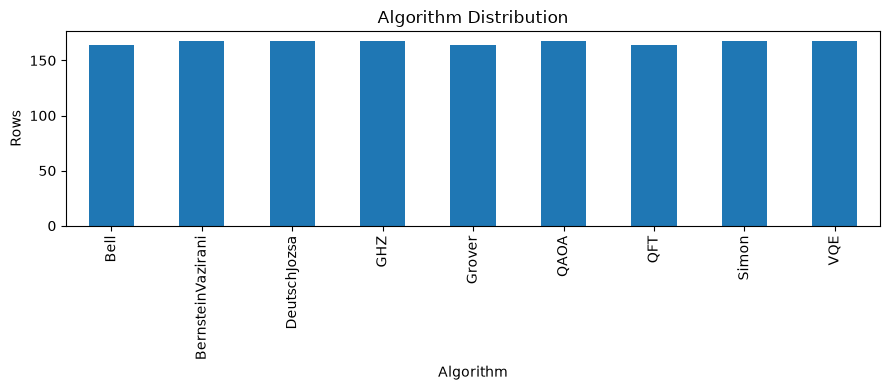

In [49]:
plt.figure(figsize=(9, 4))
df["Algorithm"].value_counts().sort_index().plot(kind="bar")
plt.title("Algorithm Distribution")
plt.xlabel("Algorithm")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

## Part 14 — Noise distribution

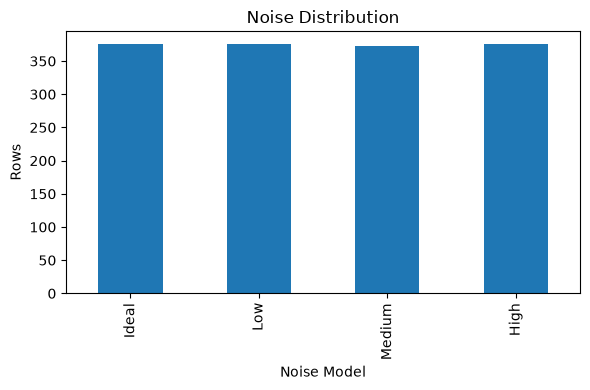

In [50]:
plt.figure(figsize=(6, 4))
df["Noise_Model"].value_counts().reindex(NOISE_LEVELS).plot(kind="bar")
plt.title("Noise Distribution")
plt.xlabel("Noise Model")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

## Part 15 — Circuit depth distribution

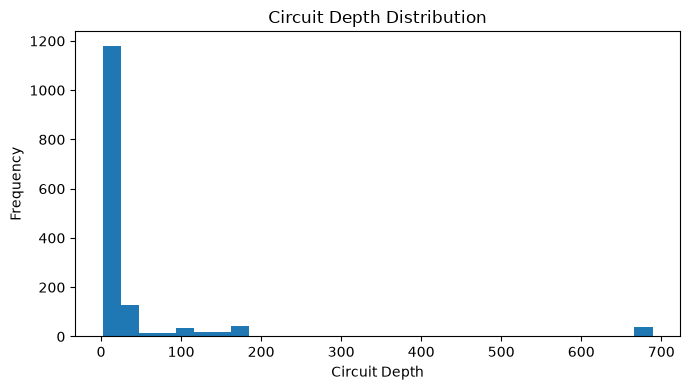

In [51]:
plt.figure(figsize=(7, 4))
plt.hist(df["Circuit_Depth"], bins=30)
plt.title("Circuit Depth Distribution")
plt.xlabel("Circuit Depth")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Part 16 — Fidelity distribution

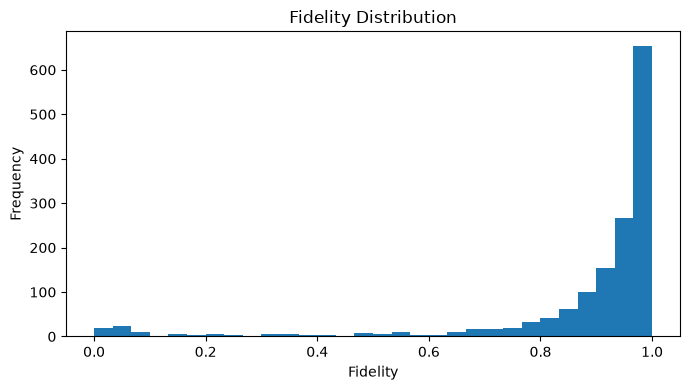

In [52]:
plt.figure(figsize=(7, 4))
plt.hist(df["Fidelity"], bins=30)
plt.title("Fidelity Distribution")
plt.xlabel("Fidelity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Part 17 — Success probability distribution

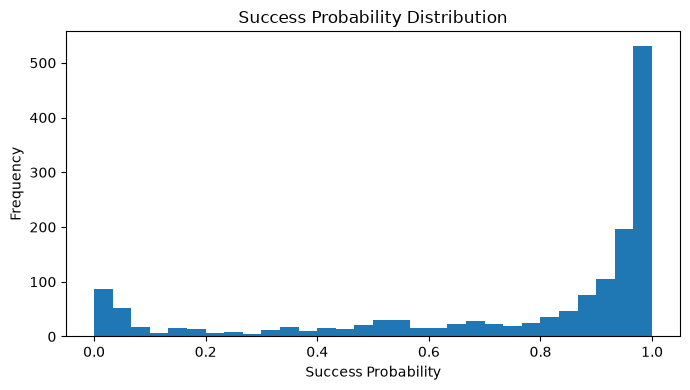

In [53]:
plt.figure(figsize=(7, 4))
plt.hist(df["Success_Probability"], bins=30)
plt.title("Success Probability Distribution")
plt.xlabel("Success Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Part 18 — Execution-time distribution

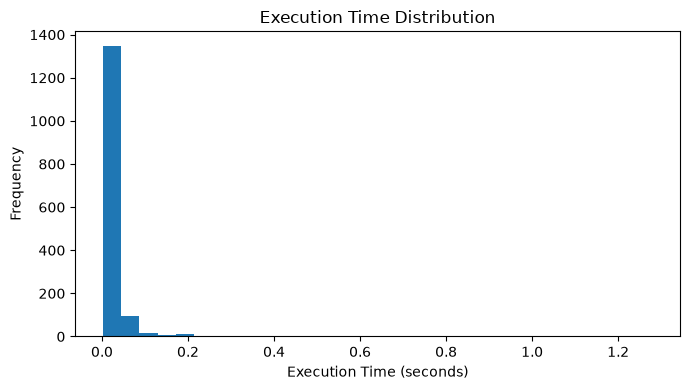

In [54]:
plt.figure(figsize=(7, 4))
plt.hist(df["Execution_Time"], bins=30)
plt.title("Execution Time Distribution")
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Part 19 — Correlation analysis

In [55]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)

target_corr = (
    corr["Success_Probability"]
    .drop("Success_Probability")
    .sort_values(key=np.abs, ascending=False)
)

print(target_corr.head(20))

RX_Gates                -0.656611
Error_Rate              -0.592077
Fidelity                 0.592077
Optimized_Total_Gates   -0.501146
CX_Gates                -0.451481
Multi_Qubit_Gates       -0.450641
Total_Gates             -0.438688
RZ_Gates                -0.431882
Optimized_Depth         -0.430552
Single_Qubit_Gates      -0.430177
Measure_Gates           -0.420208
Circuit_Depth           -0.402345
Circuit_Width           -0.344840
H_Gates                 -0.325708
Gate_Density             0.322752
Execution_Time          -0.305730
X_Gates                 -0.295451
Num_Qubits              -0.256117
Gate_Reduction           0.217507
Gate_Error_Rate         -0.196229
Name: Success_Probability, dtype: float64


## Part 20 — Depth versus performance

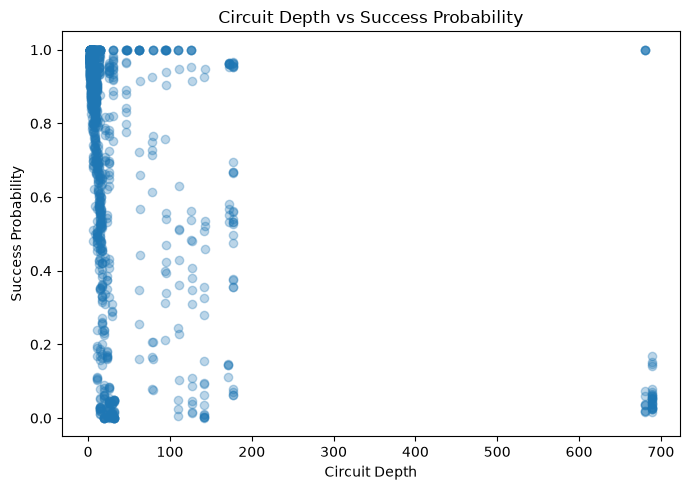

In [56]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Circuit_Depth"], df["Success_Probability"], alpha=0.30)
plt.xlabel("Circuit Depth")
plt.ylabel("Success Probability")
plt.title("Circuit Depth vs Success Probability")
plt.tight_layout()
plt.show()

# Machine Learning Pipeline
## Part 21 — Leakage-safe feature selection

PPT target: **Success Probability**

The model does not use post-execution information:
- `Execution_Time`
- `Fidelity`
- `Error_Rate`
- `Recommended_Optimization`

`Experiment_ID` is also excluded because it is only an identifier.

In [57]:
TARGET = "Success_Probability"

LEAKAGE_OR_ID_COLUMNS = [
    "Experiment_ID",
    "Execution_Time",
    "Fidelity",
    "Error_Rate",
    "Recommended_Optimization",
]

X = df.drop(columns=[TARGET] + LEAKAGE_OR_ID_COLUMNS)
y = df[TARGET].astype(float)
groups = df["Experiment_ID"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("ML input columns:", X.shape[1])
print("Categorical:", categorical_cols)
print("Numeric columns:", len(numeric_cols))

ML input columns: 31
Categorical: ['Algorithm', 'Backend', 'Noise_Model']
Numeric columns: 28


## Part 22 — Group-aware train/test split

Rows from the same `Experiment_ID` are kept together, preventing the same circuit from appearing in both training and testing.

In [58]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED,
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])

assert train_groups.isdisjoint(test_groups)

print("Train rows:", len(X_train))
print("Test rows :", len(X_test))
print("Train experiment groups:", len(train_groups))
print("Test experiment groups :", len(test_groups))

Train rows: 1200
Test rows : 300
Train experiment groups: 300
Test experiment groups : 75


## Part 23 — Encoding + Random Forest regression

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop",
)

rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Hold-out test performance")
print("-------------------------")
print(f"MAE  : {mae:.5f}")
print(f"MSE  : {mse:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R²   : {r2:.5f}")

Hold-out test performance
-------------------------
MAE  : 0.04509
MSE  : 0.01121
RMSE : 0.10589
R²   : 0.90198


## Part 24 — Group-aware 5-fold cross-validation

In [60]:
group_kfold = GroupKFold(n_splits=5)

cv_r2 = cross_val_score(
    model,
    X,
    y,
    groups=groups,
    cv=group_kfold,
    scoring="r2",
    n_jobs=-1,
)

print("Group-CV R² scores:", np.round(cv_r2, 4))
print("Mean Group-CV R² :", round(float(cv_r2.mean()), 4))
print("Std Group-CV R²  :", round(float(cv_r2.std()), 4))

Group-CV R² scores: [0.8695 0.9389 0.9072 0.9111 0.932 ]
Mean Group-CV R² : 0.9117
Std Group-CV R²  : 0.0243


## Part 25 — Actual vs predicted

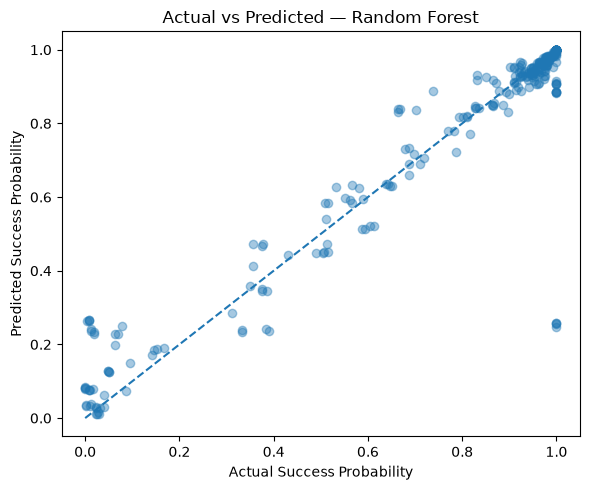

In [61]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.40)
lims = [
    min(float(y_test.min()), float(y_pred.min())),
    max(float(y_test.max()), float(y_pred.max())),
]
plt.plot(lims, lims, "--")
plt.xlabel("Actual Success Probability")
plt.ylabel("Predicted Success Probability")
plt.title("Actual vs Predicted — Random Forest")
plt.tight_layout()
plt.show()

## Part 26 — Feature importance

                       Feature  Importance
0                num__RZ_Gates    0.222673
1         num__Optimized_Depth    0.194620
2            num__Gate_Density    0.192602
3   num__Optimized_Total_Gates    0.105624
4              num__Average_T2    0.033312
5                num__RX_Gates    0.029038
6          cat__Algorithm_QAOA    0.028978
7         num__Gate_Error_Rate    0.026588
8              num__Average_T1    0.022778
9           num__Readout_Error    0.017026
10          num__Circuit_Depth    0.014824
11         num__Gate_Reduction    0.014732
12                num__H_Gates    0.012004
13               num__CX_Gates    0.011328
14               num__RY_Gates    0.011033
15      num__Multi_Qubit_Gates    0.010373
16        num__Depth_Reduction    0.009515
17             num__SWAP_Gates    0.006307
18          cat__Algorithm_QFT    0.005986
19          num__Measure_Gates    0.004770


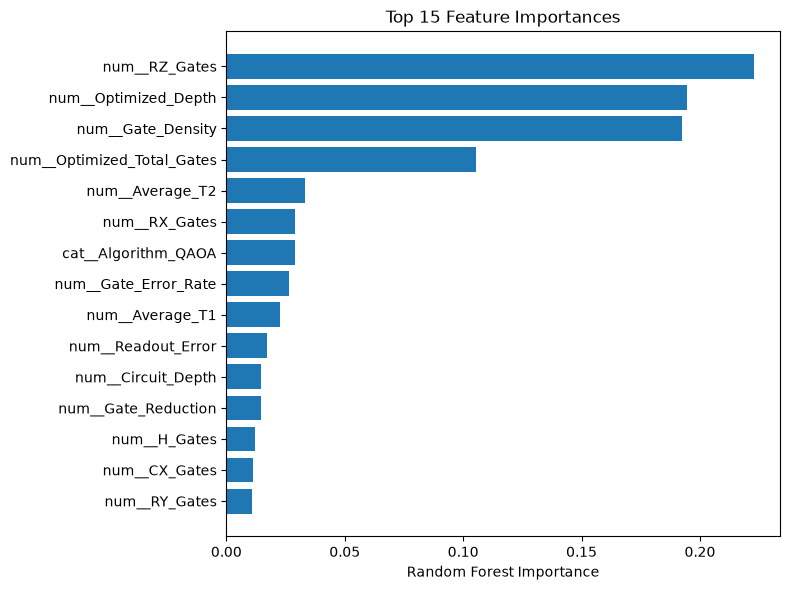

In [62]:
fitted_preprocessor = model.named_steps["preprocess"]
encoded_feature_names = fitted_preprocessor.get_feature_names_out()

importances = model.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": encoded_feature_names,
        "Importance": importances,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance.head(20))

top = feature_importance.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Random Forest Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## Part 27 — Save the baseline ML model

In [63]:
MODEL_PATH = "random_forest_success_probability.joblib"
joblib.dump(model, MODEL_PATH)
print("Saved:", MODEL_PATH)

Saved: random_forest_success_probability.joblib


# Optimization Recommendation — next stage is now supported correctly

The dataset already contains `Recommended_Optimization`, created by comparing the **same circuit** under optimization levels 0–3.

A later classifier can predict this label using only pre-execution circuit/backend information. Do not feed `Success_Probability`, `Fidelity`, `Error_Rate`, or `Execution_Time` into that classifier.

# Final checklist

- [ ] 1500 rows generated
- [ ] 375 independent `Experiment_ID` groups
- [ ] Every experiment contains optimization levels 0, 1, 2, 3
- [ ] `Optimization_Level` has exactly 375 rows per level
- [ ] `Shots` has exactly 300 rows per value
- [ ] Algorithm/backend/noise/qubit distributions are balanced or near-balanced
- [ ] No missing values
- [ ] Noise parameters stored in the CSV are actually applied
- [ ] Readout noise is applied
- [ ] T1/T2 thermal relaxation is applied
- [ ] Success probability is algorithm-aware
- [ ] Train/test split is grouped by `Experiment_ID`
- [ ] Random Forest uses group-aware cross-validation
- [ ] Recommendation labels compare optimization levels on the same circuit

In [64]:
!pip -q install openpyxl

In [66]:
y_pred = model.predict(X_test)

In [67]:
# ============================================================
# REGRESSION PERFORMANCE REPORT
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

regression_report = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

print("========== REGRESSION REPORT ==========")
display(regression_report)

========== REGRESSION REPORT ==========


,Metric,Value
0,MAE,0.045087
1,MSE,0.011213
2,RMSE,0.105893
3,R² Score,0.901976


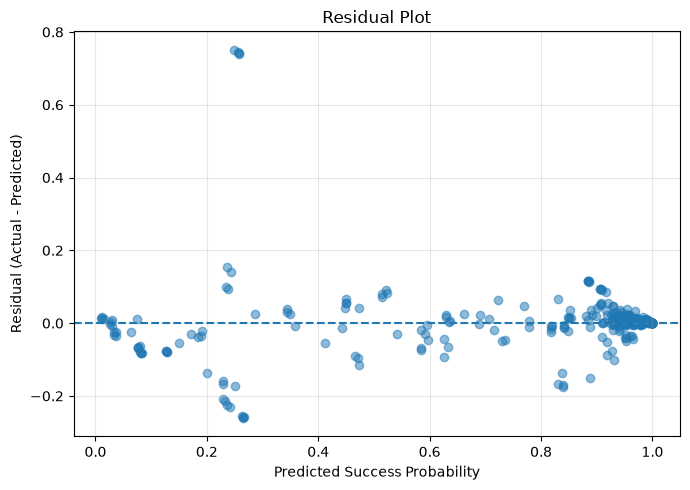

In [68]:
# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Success Probability")
plt.ylabel("Residual (Actual - Predicted)")

plt.title("Residual Plot")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
print(df.shape)

(1500, 37)


In [71]:
from pathlib import Path

# Save directly to your Downloads folder
excel_path = Path.home() / "Downloads" / "quantum_circuit_dataset_clean.xlsx"

df.to_excel(excel_path, index=False)

print("Excel file saved successfully!")
print(excel_path)

Excel file saved successfully!
C:\Users\rishi\Downloads\quantum_circuit_dataset_clean.xlsx
